## Visualize the decision boundary

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# --- CONFIGURATION ---
INPUT_CSV = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv"  # Update this!

# Column Mapping (Change these to match your CSV header)
COL_GT = "cosine_similarity"   # Ground Truth column
COL_PRED = "predicted_label"

In [9]:
# --- 1. LOAD DATA ---
print(f"Loading results from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)

# Basic Cleanup
df = df.dropna(subset=[COL_GT, COL_PRED])
print(f"Loaded {len(df)} predictions.")

Loading results from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/focal_loss/results_stratified_binary_07_dataset_test.csv...
Loaded 4858 predictions.


Generating Global Smoothness Plot...


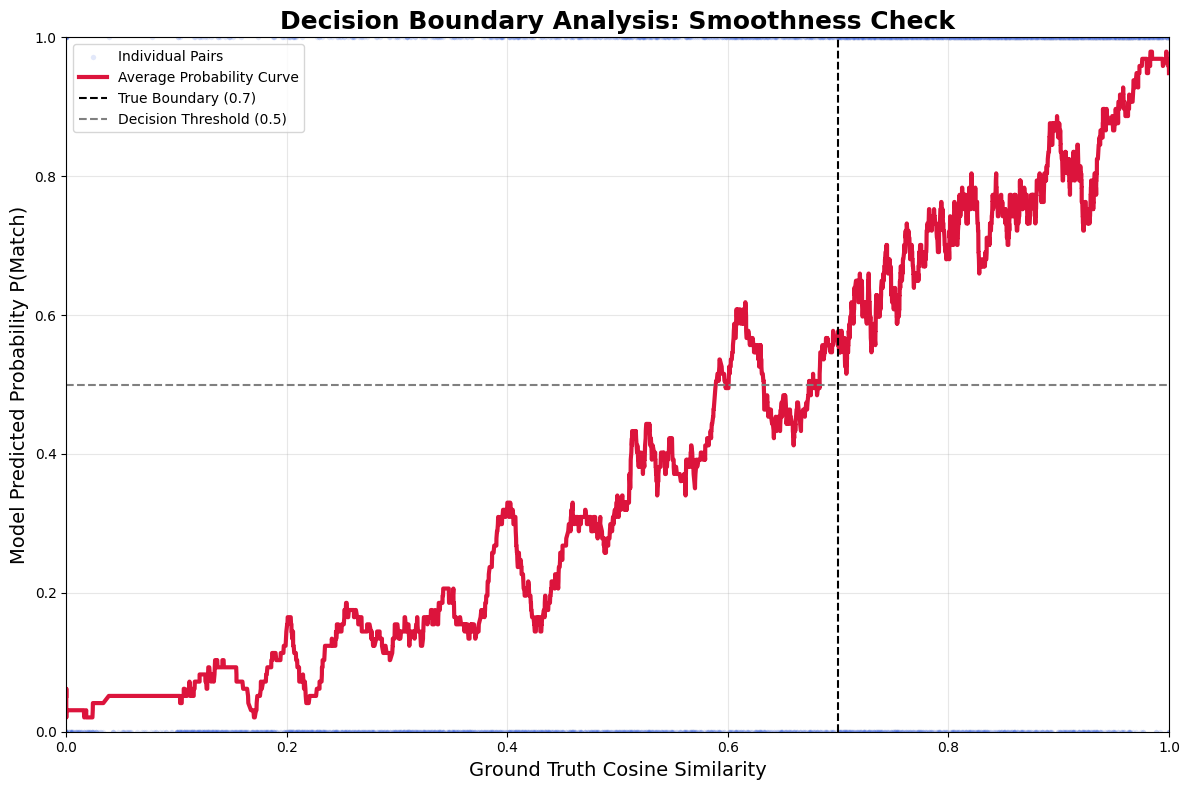

In [10]:
# --- 2. PLOT 1: THE GLOBAL S-CURVE (Scatter + Trend) ---
print("Generating Global Smoothness Plot...")
plt.figure(figsize=(12, 8))

# Downsample for scatter visibility (too many points make a solid block)
if len(df) > 10000:
    df_sample = df.sample(n=10000, random_state=42)
else:
    df_sample = df

# Scatter: Individual Pairs
sns.scatterplot(
    data=df_sample,
    x=COL_GT,
    y=COL_PRED,
    alpha=0.15,      # Low opacity to show density
    s=15,
    color='royalblue',
    label='Individual Pairs'
)

# Trend Line: The Average "S-Curve"
# We compute a rolling mean to visualize the boundary shape
df_sorted = df.sort_values(COL_GT)
# Adjust window size based on data density (approx 2% of data)
window = int(len(df) * 0.02) 
df_sorted['Rolling_Mean'] = df_sorted[COL_PRED].rolling(window=window, center=True).mean()

plt.plot(df_sorted[COL_GT], df_sorted['Rolling_Mean'], color='crimson', linewidth=3, label='Average Probability Curve')

# Reference Lines
plt.axvline(x=0.7, color='black', linestyle='--', linewidth=1.5, label='True Boundary (0.7)')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label='Decision Threshold (0.5)')

# Formatting
plt.title("Decision Boundary Analysis: Smoothness Check", fontsize=18, fontweight='bold')
plt.xlabel("Ground Truth Cosine Similarity", fontsize=14)
plt.ylabel("Model Predicted Probability P(Match)", fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show("boundary_smoothness_global.png")

Generating Variance Boxplot...


/tmp/ipykernel_2466992/2166329421.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


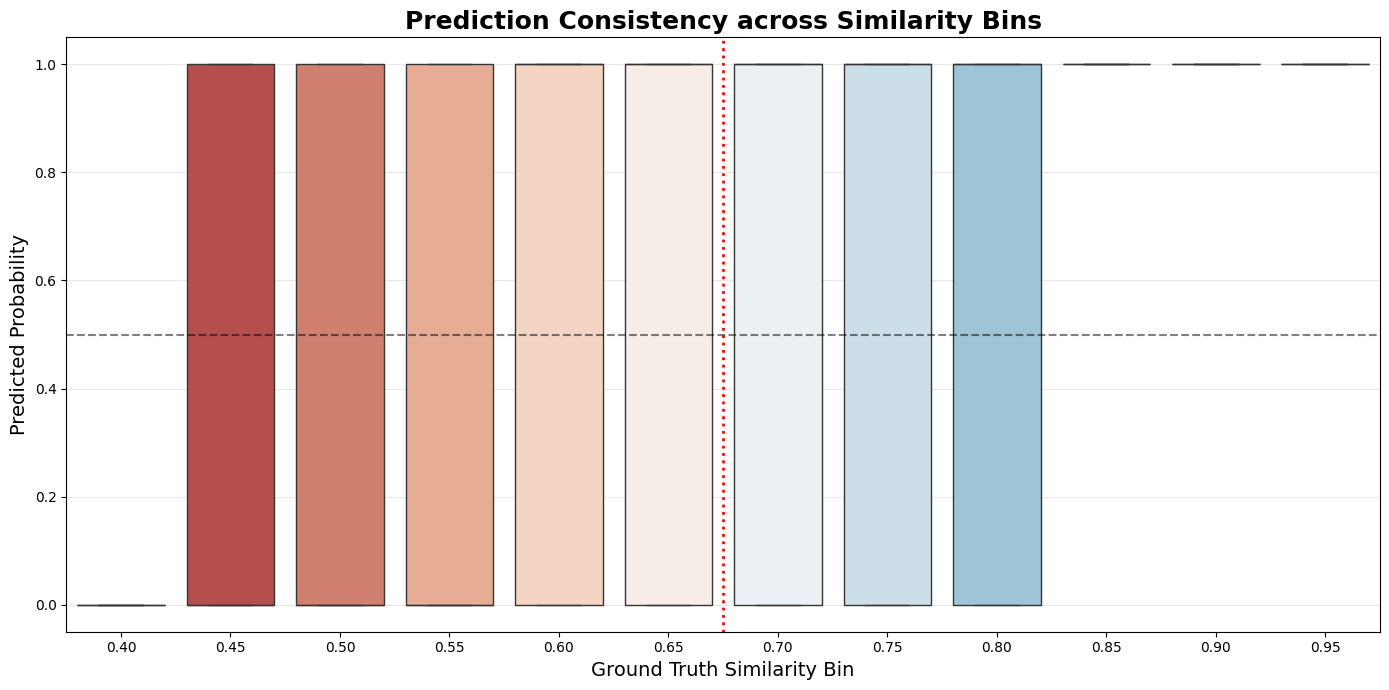

In [11]:
# --- 3. PLOT 2: THE "SPIKY" CHECK (Variance Boxplot) ---
print("Generating Variance Boxplot...")
plt.figure(figsize=(14, 7))

# Focus on the transition zone (0.4 to 1.0)
df_zoom = df[(df[COL_GT] >= 0.4) & (df[COL_GT] <= 1.0)].copy()

# Create tight bins (every 0.05) to see "jumps" or "spikes"
bins = np.arange(0.4, 1.05, 0.05)
labels = [f"{b:.2f}" for b in bins[:-1]]
df_zoom['Sim_Bin'] = pd.cut(df_zoom[COL_GT], bins=bins, labels=labels)

sns.boxplot(
    data=df_zoom, 
    x='Sim_Bin', 
    y=COL_PRED, 
    palette="RdBu", 
    showfliers=False # Hide outliers to see the median/quartiles clearly
)

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
plt.title("Prediction Consistency across Similarity Bins", fontsize=18, fontweight='bold')
plt.xlabel("Ground Truth Similarity Bin", fontsize=14)
plt.ylabel("Predicted Probability", fontsize=14)

# Highlight the 0.7 boundary bin visually
# (Assuming 0.7 falls roughly in the 6th or 7th bin depending on range)
plt.axvline(x=5.5, color='red', linestyle=':', linewidth=2, label="0.7 Boundary") 

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()